In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [2]:
DATA_DIR = "../smartvision_dataset/classification"
MODEL_DIR = "../models"

os.makedirs(MODEL_DIR, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
NUM_CLASSES = 25
EPOCHS = 5

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    f"{DATA_DIR}/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_gen = val_test_datagen.flow_from_directory(
    f"{DATA_DIR}/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_gen = val_test_datagen.flow_from_directory(
    f"{DATA_DIR}/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
def build_model(base_model, model_name):
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)
    output = Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"{model_name} model created")
    return model

In [5]:
base = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet_model = build_model(base, "MobileNetV2")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
    ModelCheckpoint(
        "../models/mobilenetv2.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_mobilenet = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 model created
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 117s 492ms/step - accuracy: 0.1297 - loss: 3.1752 - val_accuracy: 0.2213 - val_loss: 2.8580
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 83s 377ms/step - accuracy: 0.3263 - loss: 2.4819 - val_accuracy: 0.3680 - val_loss: 2.4697
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 83s 379ms/step - accuracy: 0.4389 - loss: 2.0647 - val_accuracy: 0.3707 - val_loss: 2.2896
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 83s 378ms/step - accuracy: 0.5303 - loss: 1.7476 - val_accuracy: 0.4027 - val_loss: 2.1555
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 82s 375ms/step - accuracy: 0.5789 - loss: 1.5338 - val_accuracy: 0.4000 - val_loss: 2.1024


In [6]:
test_loss, test_acc = mobilenet_model.evaluate(test_gen)

print("Test Accuracy:", round(test_acc*100,2), "%")
print("Test Loss:", test_loss)

47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 349ms/step - accuracy: 0.3147 - loss: 2.2119
Test Accuracy: 31.47 %
Test Loss: 2.2119362354278564


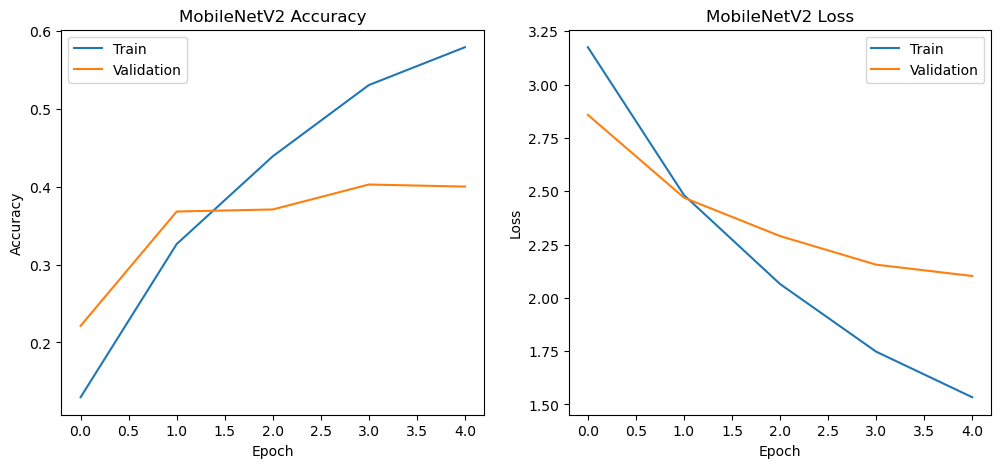

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'])
plt.plot(history_mobilenet.history['val_accuracy'])
plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'])
plt.plot(history_mobilenet.history['val_loss'])
plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(['Train','Validation'])

plt.show()

In [8]:
results = pd.DataFrame({
    "Model":["MobileNetV2"],
    "Validation Accuracy":[0.4027],
    "Training Accuracy":[0.5789]
})

results

,Model,Validation Accuracy,Training Accuracy
0,MobileNetV2,0.4027,0.5789


In [9]:
base = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

efficientnet_model = build_model(
    base,
    "EfficientNetB0"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/efficientnetb0.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_efficientnet = efficientnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
EfficientNetB0 model created
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 124s 489ms/step - accuracy: 0.0354 - loss: 3.2507 - val_accuracy: 0.0400 - val_loss: 3.2218
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 101s 461ms/step - accuracy: 0.0366 - loss: 3.2323 - val_accuracy: 0.0400 - val_loss: 3.2206
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 107s 489ms/step - accuracy: 0.0406 - loss: 3.2253 - val_accuracy: 0.0400 - val_loss: 3.2199
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 475ms/step - accuracy: 0.0411 - loss: 3.2229 - val_accuracy: 0.0400 - val_loss: 3.2195
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 105s 479ms/step - accuracy: 0.0349 - loss: 3.2231 - val_accuracy: 0.0400 - val_loss: 3.2191


In [10]:
base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

resnet_model = build_model(
    base,
    "ResNet50"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/resnet50.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_resnet = resnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
ResNet50 model created
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 225s 990ms/step - accuracy: 0.0371 - loss: 3.4010 - val_accuracy: 0.0453 - val_loss: 3.2241
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 213s 973ms/step - accuracy: 0.0554 - loss: 3.2604 - val_accuracy: 0.0880 - val_loss: 3.2200
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 211s 962ms/step - accuracy: 0.0429 - loss: 3.2347 - val_accuracy: 0.0747 - val_loss: 3.2113
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 211s 964ms/step - accuracy: 0.0497 - loss: 3.2107 - val_accuracy: 0.0560 - val_loss: 3.2100
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 210s 957ms/step - accuracy: 0.0543 - loss: 3.2025 - val_accuracy: 0.0400 - val_loss: 3.2100


In [12]:
results = pd.DataFrame({
    "Model": ["MobileNetV2", "EfficientNetB0", "ResNet50", "VGG16"],
    "Validation Accuracy": [0.4027, 0.0400, 0.0880, None],
    "Status": [
        "Trained successfully",
        "Trained but poor accuracy",
        "Trained but poor accuracy",
        "Skipped due to 8GB RAM limitation"
    ]
})

results

,Model,Validation Accuracy,Status
0,MobileNetV2,0.4027,Trained successfully
1,EfficientNetB0,0.0400,Trained but poor accuracy
2,ResNet50,0.0880,Trained but poor accuracy
3,VGG16,NaN,Skipped due to 8GB RAM limitation


In [13]:
base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

vgg_model = build_model(
    base,
    "VGG16"
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "../models/vgg16.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

history_vgg = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

VGG16 model created
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 789s 4s/step - accuracy: 0.0371 - loss: 3.3202 - val_accuracy: 0.0613 - val_loss: 3.1968
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 574s 3s/step - accuracy: 0.0691 - loss: 3.1967 - val_accuracy: 0.0880 - val_loss: 3.1525
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 490s 2s/step - accuracy: 0.0977 - loss: 3.1418 - val_accuracy: 0.1520 - val_loss: 3.1135
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 507s 2s/step - accuracy: 0.1297 - loss: 3.0793 - val_accuracy: 0.1227 - val_loss: 3.0714
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 522s 2s/step - accuracy: 0.1589 - loss: 3.0235 - val_accuracy: 0.1573 - val_loss: 3.0314
